# Fig 4: MSH2 Knockout Mouse Phylogenetic Tree and Microsatellite Library QC

## Preprocessing
- run the following commands to generate the results

```bash
#!/bin/bash
nextflow run ~/software/RETrace2/main.nf \
            --samplesheet 2025_MSH2_female_combined_samplesheet.csv \
            --output_dir results_10000targets_3000cpgs \
            --output_prefix 2025_MSH2_female_combined \
            --genome_base ~/Projects/GenomeDB \
            --genome mm39 \
            --target_bed /home/tcheng/software/RETrace2/resources/targets/mm39/RETrace2.mm39.1nt10-30bp.92460targets169818probes.bed \
            --run_methylation \
            --run_bootstrap \
            --min_targets 10000 \
            --min_cpgs 3000 \
            --celltype_ref_dir /home/tcheng/Projects/RETrace/RETrace2_methylation_ref \
            --celltype_ref_pattern "*.tsv" \
            -profile docker \
            -resume \
```

# Microsatellite Library QC
- Number of reads per cell
- Alignment rate
- Number of microsatellite targets per cell

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import glob

In [2]:
# Color scheme for tissues (defines the plotting order)
color_dict = {
    'Brain_LeftAnteriorCortex': '#678AB8',  
    'Brain_LeftPosteriorCortex': '#8FA9CC', 
    'Kidney_Left-Cortex-1': '#E68A87',            
    'Kidney_Right-Cortex-1': '#D67874',           
    'Liver_LeftLobe': '#8DA585',                  
    'Liver_RightLobe': '#A1B597',                 
    'Liver_MedianLobe': '#AEB470'                  
}

# Function to format tissue names for display
def format_tissue_name(name):
    """Convert tissue names to readable format"""
    # Replace underscores with spaces
    name = name.replace('_', ' ')
    # Add spaces before capital letters in camelCase
    name = re.sub(r'([a-z])([A-Z])', r'\1 \2', name)
    # Handle special cases like "-Cortex-1"
    name = name.replace('-', ' ')
    # Remove trailing " 1" from kidney cortex names
    name = re.sub(r'\s+1$', '', name)
    return name


## Extract Total Reads and Alignment Rate from .stats files


In [3]:
def parse_samtools_stats(stats_file):
    """
    Parse a samtools stats file to extract total reads and alignment rate.
    
    Returns a dictionary with:
    - total_reads: Total number of reads
    - alignment_rate: Percentage of reads mapped
    """
    with open(stats_file, 'r') as f:
        lines = f.readlines()
    
    # Line 1: total reads (e.g., "33255366 + 0 in total (QC-passed reads + QC-failed reads)")
    total_reads_line = lines[0].strip()
    total_reads = int(total_reads_line.split()[0])
    
    # Line 7: mapped reads with percentage (e.g., "33211939 + 0 mapped (99.87% : N/A)")
    mapped_line = lines[6].strip()  # 0-indexed, so line 7 is index 6
    # Extract percentage from parentheses
    alignment_rate = float(re.search(r'\((\d+\.\d+)%', mapped_line).group(1))
    
    return {
        'total_reads': total_reads,
        'alignment_rate': alignment_rate
    }

# Directory containing stats files
stats_dir = '/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/mapping/bam'

# Find all stats files
stats_files = glob.glob(os.path.join(stats_dir, '*.stats'))

print(f"Found {len(stats_files)} stats files")
print("Processing stats files...")

# Process all stats files
mapping_data = []
for stats_file in stats_files:
    # Extract sample_id from filename (remove .stats suffix)
    sample_id = os.path.basename(stats_file).replace('.stats', '')
    
    # Parse stats file
    try:
        stats = parse_samtools_stats(stats_file)
        stats['sample_id'] = sample_id
        mapping_data.append(stats)
    except Exception as e:
        print(f"Error parsing {sample_id}: {e}")

# Create DataFrame
df_mapping = pd.DataFrame(mapping_data)

print(f"\nSuccessfully parsed {len(df_mapping)} samples")
print("\nFirst few samples:")
df_mapping.head()


Found 216 stats files
Processing stats files...

Successfully parsed 216 samples

First few samples:


,total_reads,alignment_rate,sample_id
0,25484851,99.89,Brain_LeftAnteriorCortex_Plate1-2C
1,8403721,99.94,Kidney_Right-Cortex-1_Plate1-6D
2,11913464,99.95,Kidney_Right-Cortex-1_Plate1-6C
3,18290969,99.92,Brain_LeftAnteriorCortex_Plate1-4C
4,7475690,99.92,Liver_RightLobe_Plate1-11D


## Merge with Sample Stats and Filter for Passing Samples


In [4]:
# Read sample stats to get pass/fail information
df_stats = pd.read_csv('/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/stats/sample_stats.tsv', sep='\t')

# Merge mapping data with sample stats
df_merged = df_mapping.merge(df_stats[['sample_id', 'pass']], on='sample_id', how='left')

# Filter for passing samples only
df_mapping_pass = df_merged[df_merged['pass'] == True].copy()

# Extract detailed tissue names (first two parts before "_Plate")
df_mapping_pass['tissue_detail'] = df_mapping_pass['sample_id'].str.extract(r'(.+?)_Plate')[0]

# Get tissues in the order specified by color_dict, filter to only those present in data
unique_tissues = [t for t in color_dict.keys() if t in df_mapping_pass['tissue_detail'].values]
tissue_colors = [color_dict[t] for t in unique_tissues]
tissue_labels = [format_tissue_name(t) for t in unique_tissues]

# Convert tissue_detail to categorical with specified order for proper plotting
df_mapping_pass['tissue_detail'] = pd.Categorical(df_mapping_pass['tissue_detail'], 
                                                   categories=unique_tissues, 
                                                   ordered=True)

print(f"\nTotal passing samples: {len(df_mapping_pass)}")
print(f"\nSamples per tissue:\n{df_mapping_pass['tissue_detail'].value_counts()}")
print(f"\nSummary statistics:")
print(df_mapping_pass[['total_reads', 'alignment_rate']].describe())



Total passing samples: 152

Samples per tissue:
tissue_detail
Brain_LeftPosteriorCortex    36
Brain_LeftAnteriorCortex     35
Kidney_Right-Cortex-1        30
Liver_LeftLobe               18
Liver_MedianLobe             17
Liver_RightLobe              10
Kidney_Left-Cortex-1          6
Name: count, dtype: int64

Summary statistics:
        total_reads  alignment_rate
count  1.520000e+02      152.000000
mean   1.269450e+07       99.865395
std    7.755699e+06        0.067293
min    3.219097e+06       99.640000
25%    7.254990e+06       99.820000
50%    1.097576e+07       99.890000
75%    1.634394e+07       99.920000
max    6.145184e+07       99.960000


## Plot Total Reads by Tissue


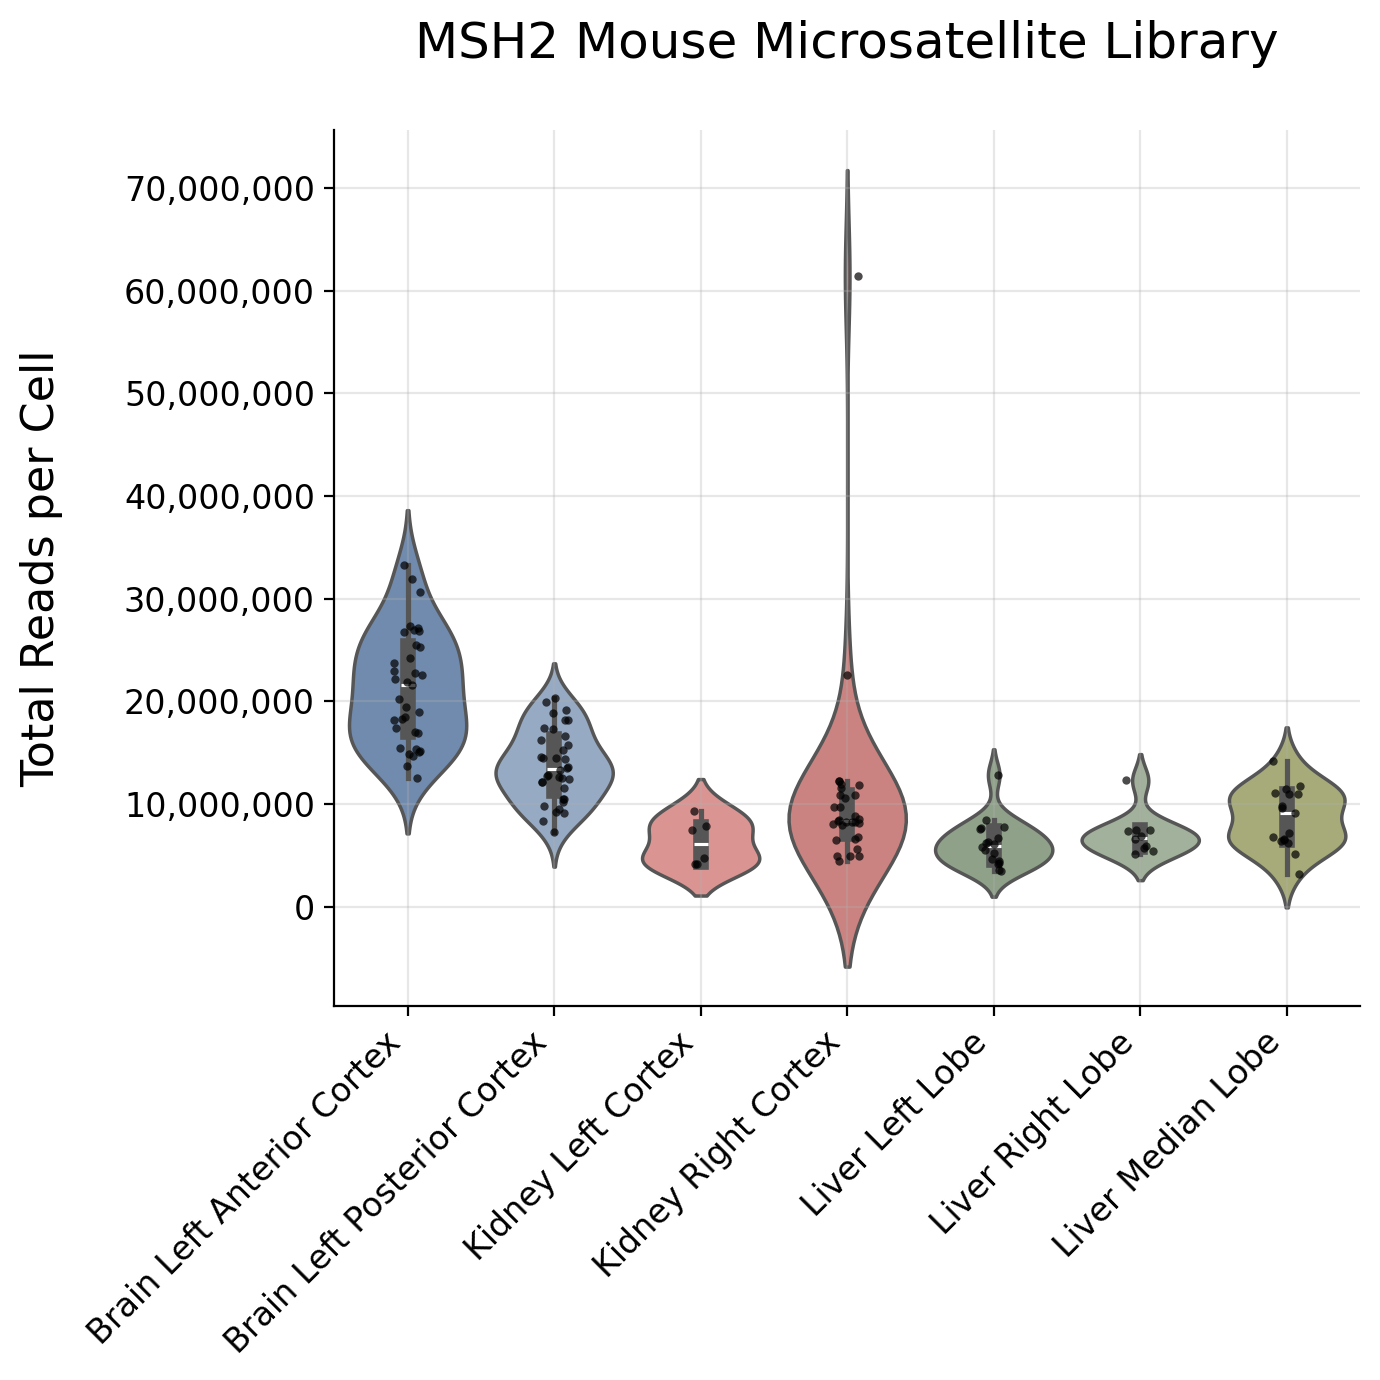


Total Reads Summary Statistics:
                           count          mean           std         min  \
tissue_detail                                                              
Brain_LeftAnteriorCortex    35.0  2.130084e+07  5.468188e+06  12504802.0   
Brain_LeftPosteriorCortex   36.0  1.375494e+07  3.477452e+06   7291914.0   
Kidney_Left-Cortex-1         6.0  6.289434e+06  2.211212e+06   4175450.0   
Kidney_Right-Cortex-1       30.0  1.077290e+07  1.017228e+07   4463991.0   
Liver_LeftLobe              18.0  6.143922e+06  2.235725e+06   3481017.0   
Liver_RightLobe             10.0  7.041460e+06  2.036553e+06   5151841.0   
Liver_MedianLobe            17.0  8.642849e+06  2.899572e+06   3219097.0   

                                   25%         50%          75%         max  
tissue_detail                                                                
Brain_LeftAnteriorCortex   16977368.50  21632919.0  25375736.00  33255366.0  
Brain_LeftPosteriorCortex  11259758.25  13408706

/tmp/ipykernel_1753801/1158662151.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_mapping_pass.groupby('tissue_detail')['total_reads'].describe())


In [5]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

sns.violinplot(x='tissue_detail', y='total_reads', data=df_mapping_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='total_reads', data=df_mapping_pass, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("MSH2 Mouse Microsatellite Library\n", fontsize=18)
ax.set_ylabel('Total Reads per Cell\n', fontsize=16)

ax.tick_params(axis='both', labelsize=12)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues)))
ax.set_xticklabels(tissue_labels, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Format y-axis to show numbers with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('total_reads_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nTotal Reads Summary Statistics:")
print(df_mapping_pass.groupby('tissue_detail')['total_reads'].describe())


## Plot Alignment Rate by Tissue


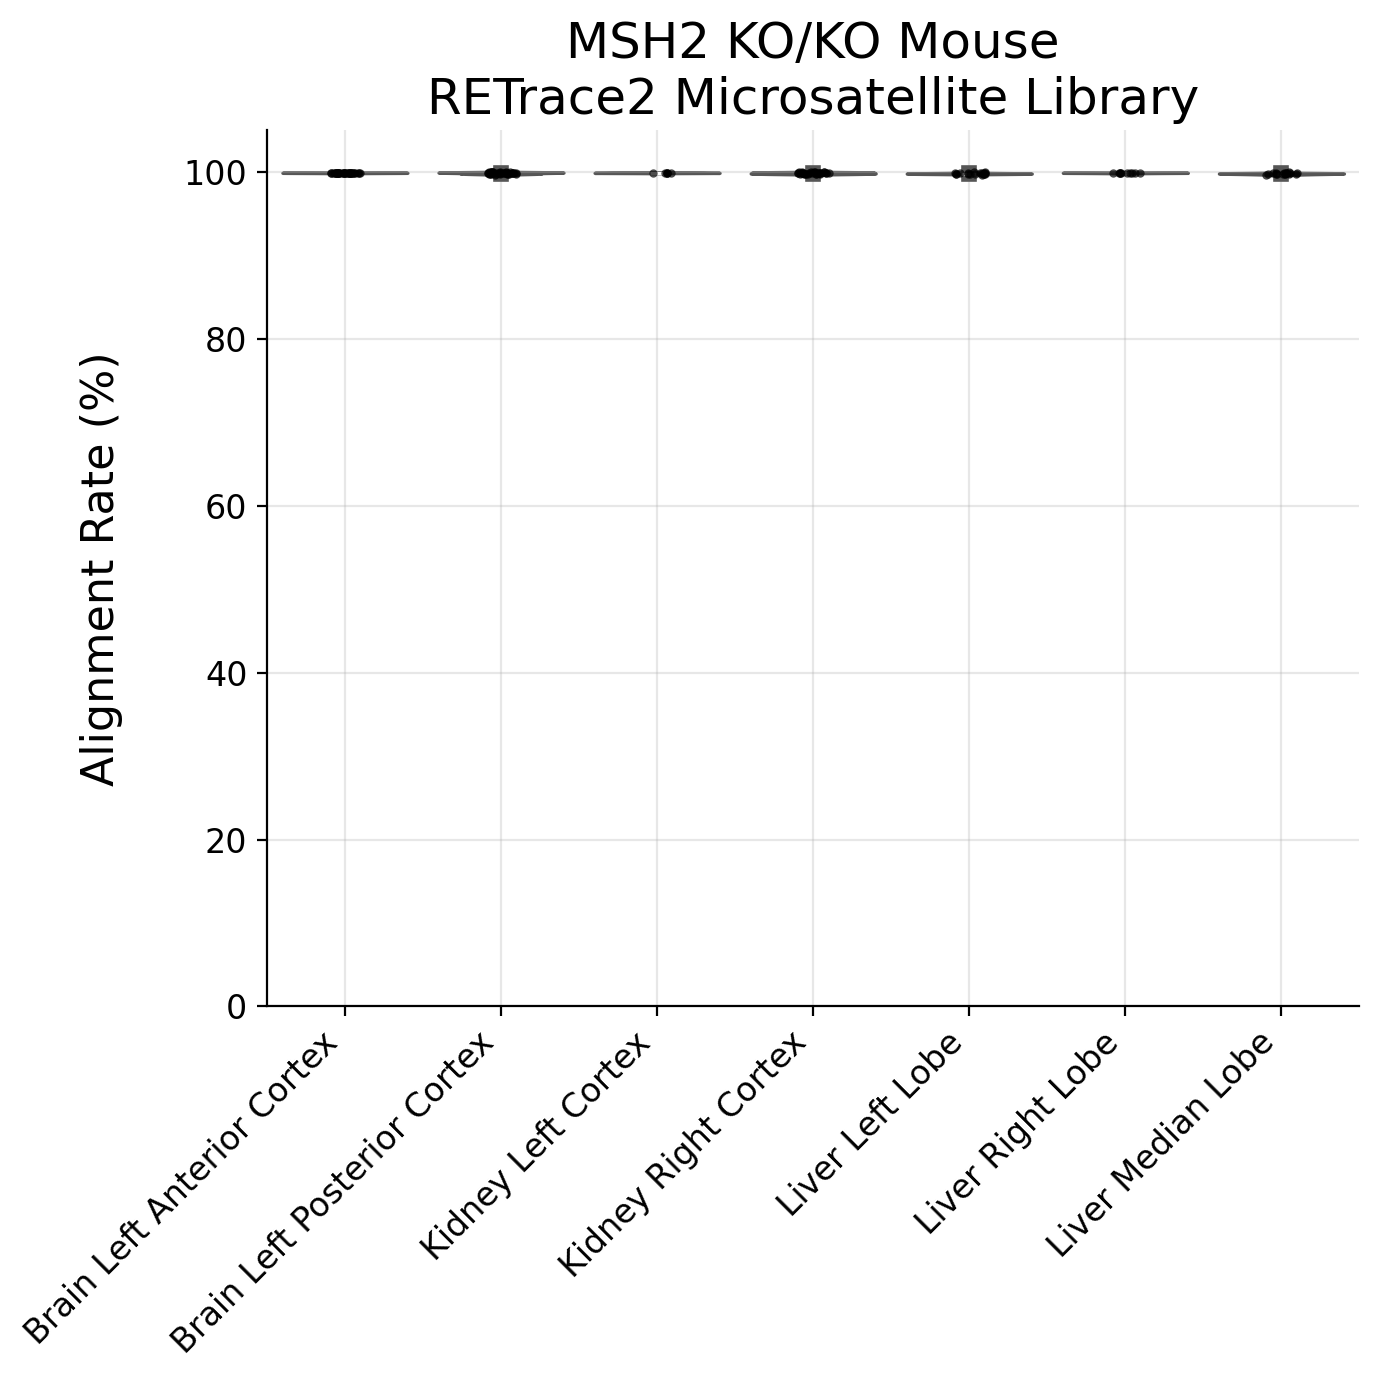


Alignment Rate Summary Statistics:
                           count       mean       std    min      25%     50%  \
tissue_detail                                                                   
Brain_LeftAnteriorCortex    35.0  99.901714  0.015809  99.87  99.8900  99.900   
Brain_LeftPosteriorCortex   36.0  99.865833  0.081218  99.64  99.8100  99.890   
Kidney_Left-Cortex-1         6.0  99.908333  0.018348  99.89  99.8925  99.905   
Kidney_Right-Cortex-1       30.0  99.864000  0.069906  99.74  99.8075  99.855   
Liver_LeftLobe              18.0  99.820556  0.060728  99.68  99.7925  99.815   
Liver_RightLobe             10.0  99.900000  0.016330  99.87  99.8925  99.900   
Liver_MedianLobe            17.0  99.804118  0.064523  99.66  99.7800  99.810   

                               75%    max  
tissue_detail                              
Brain_LeftAnteriorCortex   99.9100  99.93  
Brain_LeftPosteriorCortex  99.9325  99.95  
Kidney_Left-Cortex-1       99.9250  99.93  
Kidney_Right-C

/tmp/ipykernel_1753801/2642923591.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_mapping_pass.groupby('tissue_detail')['alignment_rate'].describe())


In [6]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

sns.violinplot(x='tissue_detail', y='alignment_rate', data=df_mapping_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='alignment_rate', data=df_mapping_pass, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("MSH2 KO/KO Mouse\nRETrace2 Microsatellite Library", fontsize=18)
ax.set_ylabel('Alignment Rate (%)\n', fontsize=16)

ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(0, 105)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues)))
ax.set_xticklabels(tissue_labels, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('alignment_rate_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nAlignment Rate Summary Statistics:")
print(df_mapping_pass.groupby('tissue_detail')['alignment_rate'].describe())


## Plot Number of Targets per Cell

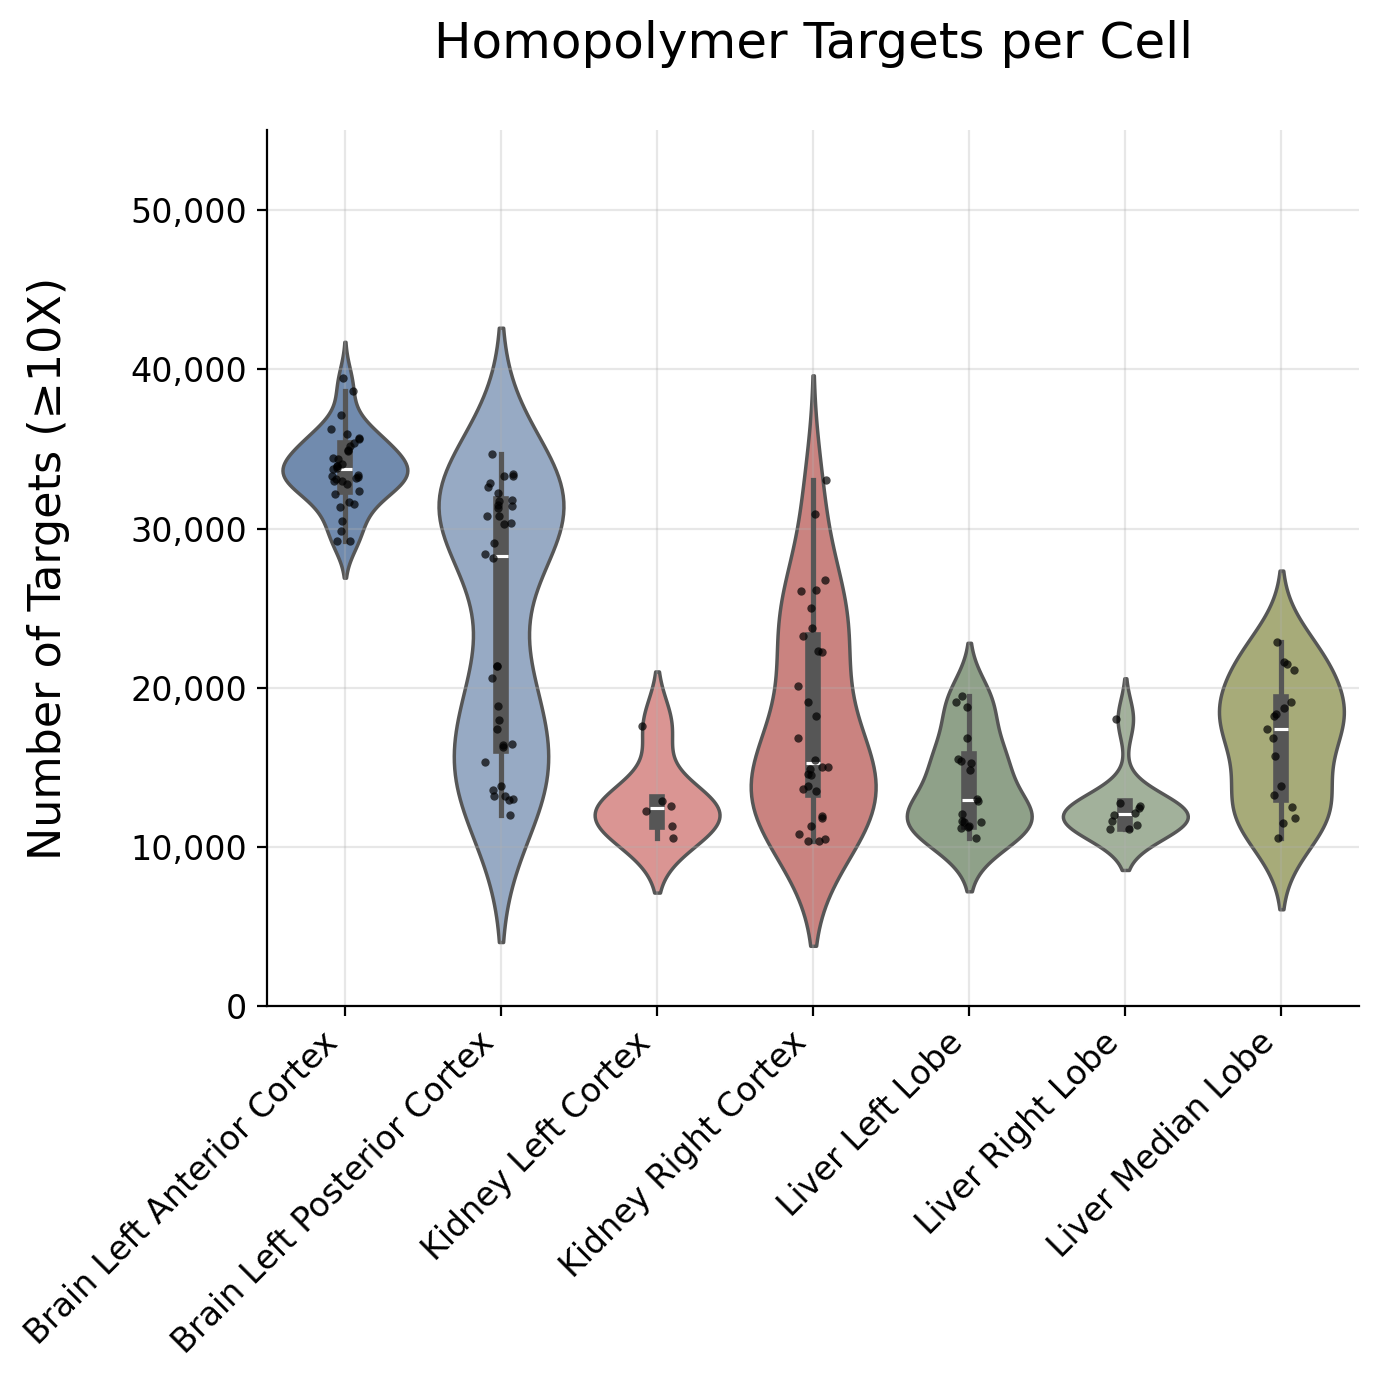


Number of Targets (≥10X) Summary Statistics:
                           count          mean          std      min  \
tissue_detail                                                          
Brain_LeftAnteriorCortex    35.0  33714.600000  2329.703139  29201.0   
Brain_LeftPosteriorCortex   36.0  24213.416667  8144.102000  11998.0   
Kidney_Left-Cortex-1         6.0  12887.333333  2459.019290  10584.0   
Kidney_Right-Cortex-1       30.0  18055.666667  6466.547436  10358.0   
Liver_LeftLobe              18.0  14029.333333  2976.184688  10568.0   
Liver_RightLobe             10.0  12532.700000  2023.446293  11121.0   
Liver_MedianLobe            17.0  16776.352941  3930.482062  10560.0   

                                25%      50%       75%      max  
tissue_detail                                                    
Brain_LeftAnteriorCortex   32589.00  33707.0  35056.00  39431.0  
Brain_LeftPosteriorCortex  16360.25  28282.5  31526.25  34650.0  
Kidney_Left-Cortex-1       11586.25  1244

/tmp/ipykernel_1753801/1175535292.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_targets_pass.groupby('tissue_detail')['ms_targets_with_min_reads'].describe())


In [7]:
# Read sample stats for target counts
df_stats_full = pd.read_csv('/home/tcheng/Projects/RETrace/2025_RETrace2_MSH2_Female_Combined/results_10000targets_3000cpgs/stats/sample_stats.tsv', sep='\t')

# Filter for passing samples only
df_targets_pass = df_stats_full[df_stats_full['pass'] == True].copy()

# Extract detailed tissue names
df_targets_pass['tissue_detail'] = df_targets_pass['sample_id'].str.extract(r'(.+?)_Plate')[0]

# Get tissues in the order specified by color_dict
unique_tissues_targets = [t for t in color_dict.keys() if t in df_targets_pass['tissue_detail'].values]
tissue_colors_targets = [color_dict[t] for t in unique_tissues_targets]
tissue_labels_targets = [format_tissue_name(t) for t in unique_tissues_targets]

# Convert tissue_detail to categorical with specified order
df_targets_pass['tissue_detail'] = pd.Categorical(df_targets_pass['tissue_detail'], 
                                                   categories=unique_tissues_targets, 
                                                   ordered=True)

fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

sns.violinplot(x='tissue_detail', y='ms_targets_with_min_reads', data=df_targets_pass, hue='tissue_detail', 
               palette=tissue_colors_targets, legend=False, ax=ax)
sns.stripplot(x='tissue_detail', y='ms_targets_with_min_reads', data=df_targets_pass, color='black', ax=ax, size=3, alpha=0.7)

ax.set_xlabel("")
ax.set_title("Homopolymer Targets per Cell\n", fontsize=18)
ax.set_ylabel('Number of Targets (≥10X)\n', fontsize=16)

ax.tick_params(axis='both', labelsize=12)

# Set the tick locations and labels with formatted names
ax.set_xticks(range(len(unique_tissues_targets)))
ax.set_xticklabels(tissue_labels_targets, rotation=45, ha='right')

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylim(0, 55000)

# Format y-axis to show numbers with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('targets_per_cell_by_tissue_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nNumber of Targets (≥10X) Summary Statistics:")
print(df_targets_pass.groupby('tissue_detail')['ms_targets_with_min_reads'].describe())


## Combined Plot: Total Reads and Number of Targets


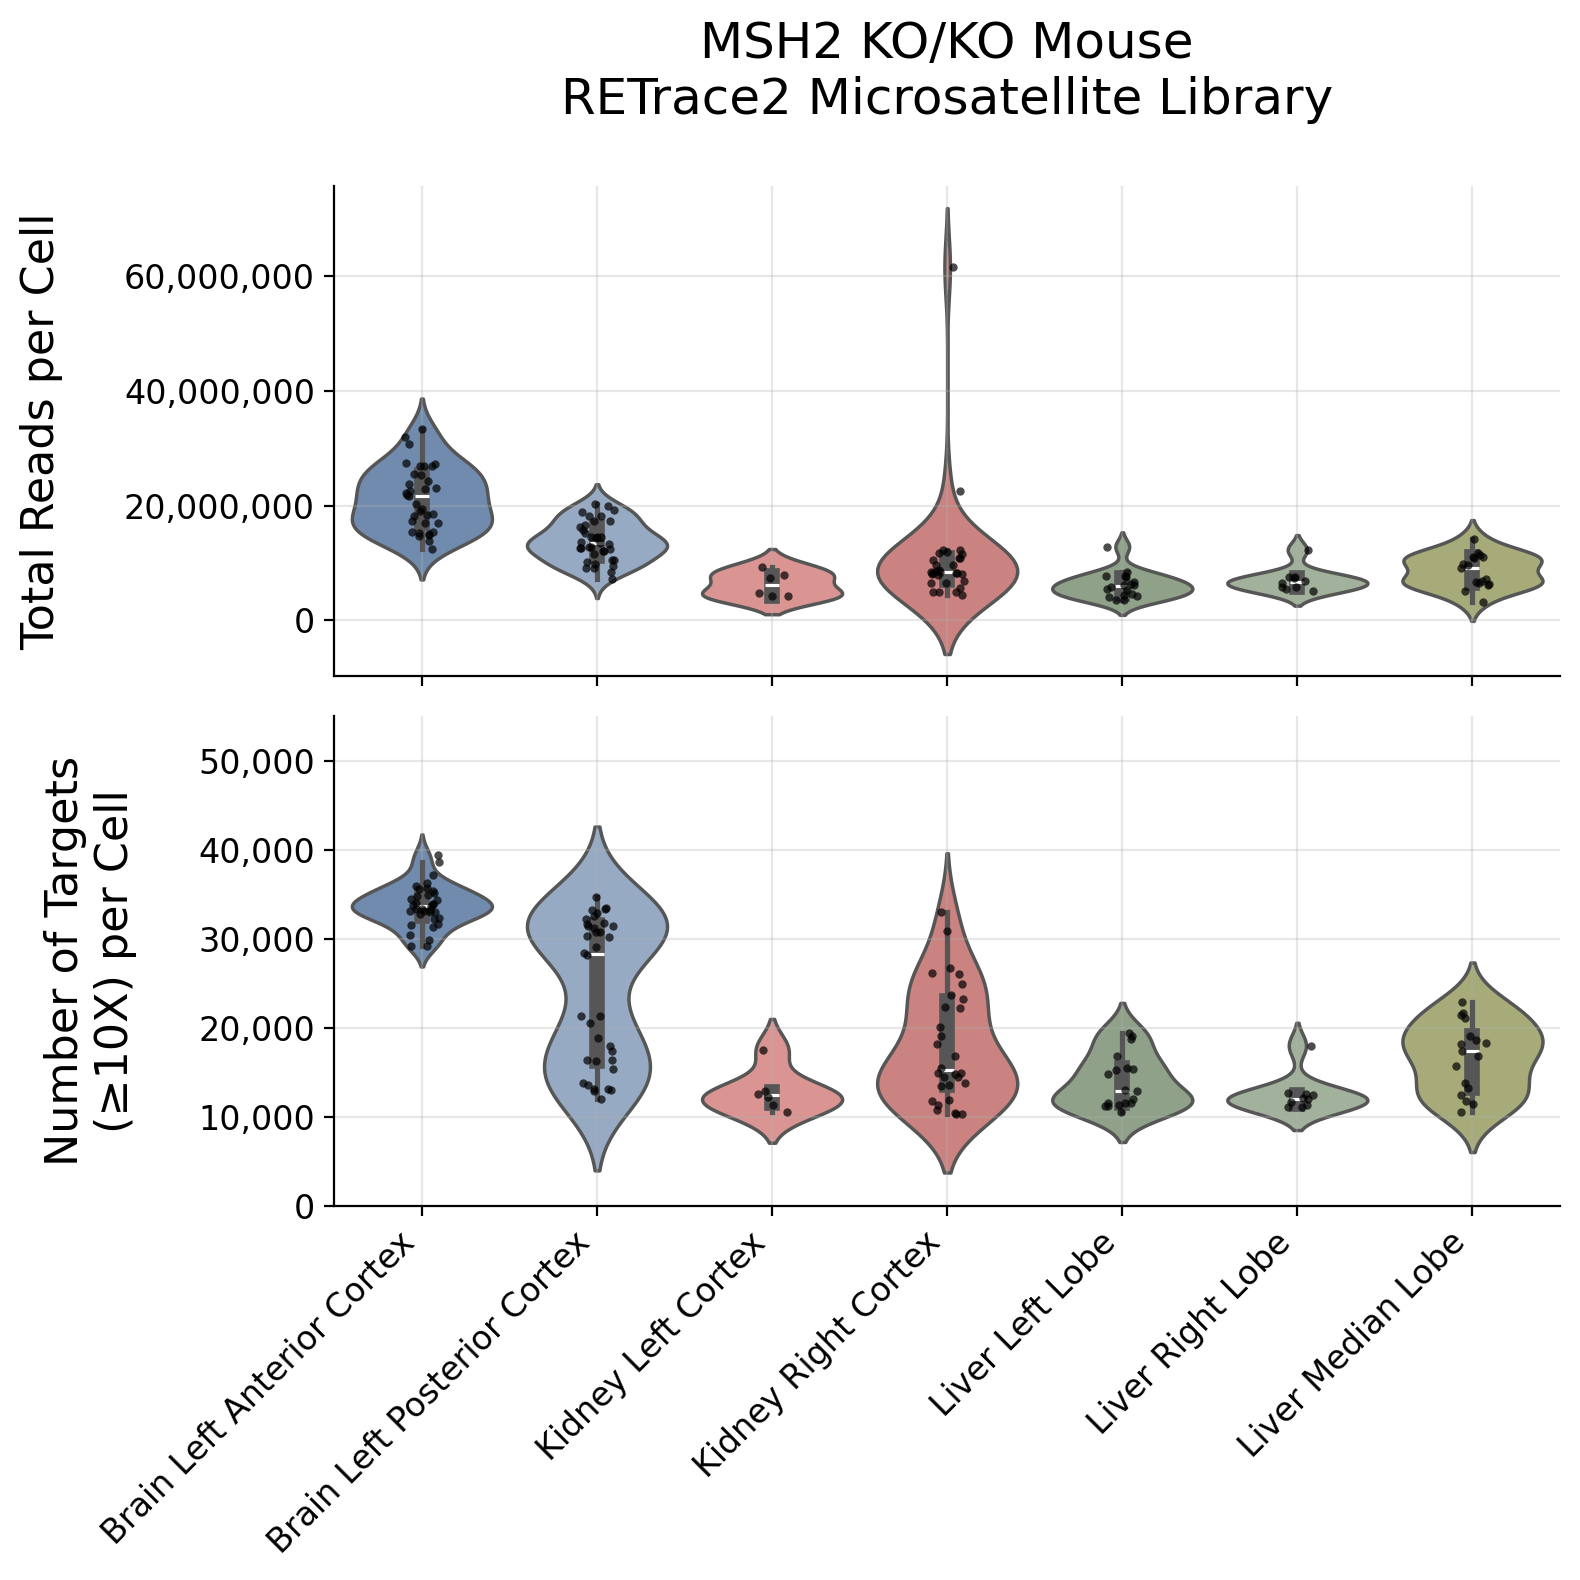

In [8]:
# Create 2-panel combined plot
fig, axes = plt.subplots(2, 1, figsize=(8, 8), dpi=200)

# Top panel: Total Reads
ax1 = axes[0]
sns.violinplot(x='tissue_detail', y='total_reads', data=df_mapping_pass, hue='tissue_detail', 
               palette=tissue_colors, legend=False, ax=ax1)
sns.stripplot(x='tissue_detail', y='total_reads', data=df_mapping_pass, color='black', ax=ax1, size=3, alpha=0.7)

ax1.set_xlabel("")
ax1.set_title("MSH2 KO/KO Mouse\nRETrace2 Microsatellite Library\n", fontsize=18)
ax1.set_ylabel('Total Reads per Cell\n', fontsize=16)
ax1.tick_params(axis='both', labelsize=12)
ax1.set_xticks(range(len(unique_tissues)))
ax1.set_xticklabels([])  # Remove x-tick labels for top panel
ax1.grid(True, alpha=0.3)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bottom panel: Number of Targets
ax2 = axes[1]
sns.violinplot(x='tissue_detail', y='ms_targets_with_min_reads', data=df_targets_pass, hue='tissue_detail', 
               palette=tissue_colors_targets, legend=False, ax=ax2)
sns.stripplot(x='tissue_detail', y='ms_targets_with_min_reads', data=df_targets_pass, color='black', ax=ax2, size=3, alpha=0.7)

ax2.set_xlabel("")
ax2.set_ylabel('Number of Targets\n(≥10X) per Cell\n', fontsize=16)
ax2.tick_params(axis='both', labelsize=12)
ax2.set_ylim(0, 55000)
ax2.set_xticks(range(len(unique_tissues_targets)))
ax2.set_xticklabels(tissue_labels_targets, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('total_reads_and_n_targets_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Overall Summary Statistics


In [9]:
# Create comprehensive summary table for all passing samples including targets
print("="*80)
print("OVERALL SUMMARY STATISTICS - ALL PASSING SAMPLES")
print("="*80)
print(f"\nTotal Passing Samples: {len(df_mapping_pass)}")
print("\n" + "-"*80)

# Create summary dataframe
summary_data = {
    'Metric': [
        'Total Reads',
        'Alignment Rate (%)',
        'Number of Targets (≥10X)'
    ],
    'Mean': [
        df_mapping_pass['total_reads'].mean(),
        df_mapping_pass['alignment_rate'].mean(),
        df_targets_pass['ms_targets_with_min_reads'].mean()
    ],
    'Median': [
        df_mapping_pass['total_reads'].median(),
        df_mapping_pass['alignment_rate'].median(),
        df_targets_pass['ms_targets_with_min_reads'].median()
    ],
    'Std Dev': [
        df_mapping_pass['total_reads'].std(),
        df_mapping_pass['alignment_rate'].std(),
        df_targets_pass['ms_targets_with_min_reads'].std()
    ],
    'Min': [
        df_mapping_pass['total_reads'].min(),
        df_mapping_pass['alignment_rate'].min(),
        df_targets_pass['ms_targets_with_min_reads'].min()
    ],
    'Max': [
        df_mapping_pass['total_reads'].max(),
        df_mapping_pass['alignment_rate'].max(),
        df_targets_pass['ms_targets_with_min_reads'].max()
    ]
}

summary_df = pd.DataFrame(summary_data)

# Format the display
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(summary_df.to_string(index=False))
pd.reset_option('display.float_format')

print("\n" + "="*80)


OVERALL SUMMARY STATISTICS - ALL PASSING SAMPLES

Total Passing Samples: 152

--------------------------------------------------------------------------------
                  Metric          Mean        Median      Std Dev          Min           Max
             Total Reads 12,694,503.74 10,975,764.50 7,755,699.08 3,219,097.00 61,451,841.00
      Alignment Rate (%)         99.87         99.89         0.07        99.64         99.96
Number of Targets (≥10X)     21,932.51     18,982.50     9,145.98    10,358.00     39,431.00

